In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

In [6]:
train_df.shape

(27455, 785)

In [7]:
test_df.shape

(7172, 785)

In [8]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [9]:
y_train = train_df['label'].values

In [11]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [10]:
y_test = test_df['label'].values

In [15]:
y_test[:20]

array([ 6,  5, 10,  0,  3, 21, 10, 14,  3,  7,  8,  8, 21, 12,  7,  4, 22,
        0,  7,  7], dtype=int64)

In [12]:
X_train = train_df.drop('label', axis=1).values
X_test = test_df.drop('label', axis=1).values

In [13]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [16]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [21]:
unique_labels = sorted(np.unique(np.concatenate([y_train, y_test])))

In [22]:
label_map = {old: new for new, old in enumerate(unique_labels)}
label_map

{0: 0,
 1: 1,
 2: 2,
 3: 3,
 4: 4,
 5: 5,
 6: 6,
 7: 7,
 8: 8,
 10: 9,
 11: 10,
 12: 11,
 13: 12,
 14: 13,
 15: 14,
 16: 15,
 17: 16,
 18: 17,
 19: 18,
 20: 19,
 21: 20,
 22: 21,
 23: 22,
 24: 23}

In [23]:
y_train = np.array([label_map[y] for y in y_train])
y_test = np.array([label_map[y] for y in y_test])

In [24]:
len(unique_labels)

24

In [28]:
num_classes = len(unique_labels)
num_classes

24

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].squeeze(), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
    
plt.tight_layout()
plt.savefig('sample_images.png')
plt.close()
print("Sample images saved as 'sample_images.png'.")

Sample images saved as 'sample_images.png'.


In [29]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10


194/194 [==============================] - 9s 27ms/step - loss: 2.5996 - accuracy: 0.2056 - val_loss: 1.5531 - val_accuracy: 0.5237
Epoch 2/10
194/194 [==============================] - 5s 24ms/step - loss: 1.4631 - accuracy: 0.5127 - val_loss: 0.9573 - val_accuracy: 0.6886
Epoch 3/10
194/194 [==============================] - 5s 24ms/step - loss: 1.0147 - accuracy: 0.6486 - val_loss: 0.5602 - val_accuracy: 0.8128
Epoch 4/10
194/194 [==============================] - 5s 25ms/step - loss: 0.7850 - accuracy: 0.7214 - val_loss: 0.2892 - val_accuracy: 0.9279
Epoch 5/10
194/194 [==============================] - 5s 27ms/step - loss: 0.6066 - accuracy: 0.7815 - val_loss: 0.2241 - val_accuracy: 0.9403
Epoch 6/10
194/194 [==============================] - 5s 25ms/step - loss: 0.5039 - accuracy: 0.8157 - val_loss: 0.2132 - val_accuracy: 0.9403
Epoch 7/10
194/194 [==============================] - 5s 26ms/step - loss: 0.4649 - accuracy: 0.8288 - val_loss: 0.1186 - val_accuracy: 0.96

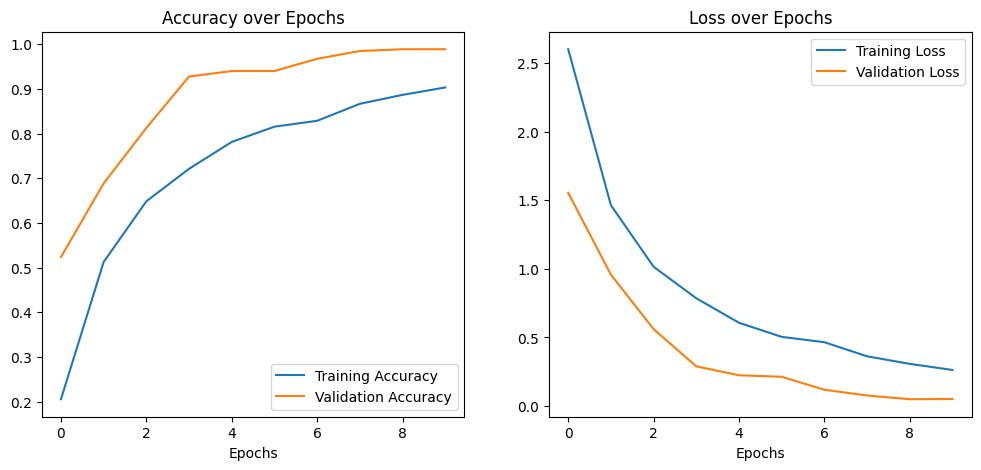

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epochs')
ax1.legend()

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epochs')
ax2.legend()

In [33]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

225/225 [==============================] - 2s 8ms/step - loss: 0.3006 - accuracy: 0.9066
Test Loss: 0.3006, Test Accuracy: 0.9066


In [34]:
model.predict(X_test)

225/225 [==============================] - 2s 8ms/step


array([[6.03389172e-15, 1.64717602e-18, 2.80192296e-04, ...,
        3.15126961e-17, 1.77725651e-05, 2.22286755e-11],
       [1.39239248e-07, 5.19134570e-03, 1.95306299e-10, ...,
        4.89929207e-02, 5.62189371e-07, 1.09971715e-07],
       [3.55129428e-22, 3.43060514e-13, 3.50766931e-16, ...,
        2.52791055e-09, 2.46199619e-07, 8.48961013e-10],
       ...,
       [4.85320935e-25, 2.89376748e-30, 9.98999178e-01, ...,
        1.60844580e-36, 1.25058475e-09, 4.09375495e-33],
       [3.26359525e-14, 6.74901940e-11, 3.08381223e-13, ...,
        1.19128720e-21, 1.86135050e-14, 2.88091496e-33],
       [4.92237125e-26, 1.08413611e-31, 9.99550045e-01, ...,
        0.00000000e+00, 1.56771360e-10, 9.66668927e-35]], dtype=float32)

In [35]:
y_pred = np.argmax(model.predict(X_test), axis=1)

225/225 [==============================] - 2s 7ms/step


In [36]:
y_pred

array([6, 5, 9, ..., 2, 4, 2], dtype=int64)

In [37]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[327   0   0   0   4   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0 411   0   0   0   0   0   0  19   2   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0 299   0   0   0   0   0   0   0   0   0   0  11   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0 225  16   0   0   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   2   0]
 [  0   0   0   0 490   0   0   0   0   0   0   0   0   0   0   0   0   8
    0   0   0   0   0   0]
 [  0   0   0   0   0 247   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0 248   0   0   0   0   0   0   0  34   4   0   0
   62   0   0   0   0   0]
 [  0   0   0   0   0   0  20 416   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 284   0   0   0   0   0   0   0   0   0
    0   0   4   0   0   0]
 [  0   0   0   0   0   0   0   0   0 308   0   0   0   0   0   0   0   0
    0  21   0   0

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.savefig('confusion_matrix.png')
plt.close()

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       331
           1       1.00      0.95      0.98       432
           2       1.00      0.96      0.98       310
           3       1.00      0.92      0.96       245
           4       0.85      0.98      0.91       498
           5       0.92      1.00      0.96       247
           6       0.93      0.71      0.81       348
           7       0.99      0.95      0.97       436
           8       0.80      0.99      0.88       288
           9       0.99      0.93      0.96       331
          10       0.96      1.00      0.98       209
          11       0.84      0.89      0.86       394
          12       0.99      0.65      0.78       291
          13       0.96      0.98      0.97       246
          14       0.90      0.89      0.89       347
          15       0.85      0.95      0.90       164
          16       0.89      0.58      0.71       144
          17       0.85    

In [47]:
model.save('sign_language_cnn.keras')

In [48]:
from tensorflow.keras.models import load_model
model = load_model('sign_language_cnn.keras')

In [50]:
sample_idx = 0

sample_image = X_test[sample_idx : sample_idx + 1]
prediction = model.predict(sample_image)
predicted_class = np.argmax(prediction)

1/1 [==============================] - 0s 174ms/step


In [53]:
print(f'Demp prediction on test image # {sample_idx}')
print(f"True label index : {y_test[sample_idx]}, Predicted label index: {predicted_class}")

Demp prediction on test image # 0
True label index : 6, Predicted label index: 6


In [55]:
print(f"Confidence scores for each class: {prediction[0][predicted_class]}")

Confidence scores for each class: 0.9992547631263733
